<a href="https://colab.research.google.com/github/bensonmacharia/ML/blob/main/martingale_dca_lumpsum_bitcoin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Martingale, Dollar Cost Averaging and Lump Sum for Bitcoin with Python

This notebook compares three Bitcoin investment strategies using historical data:

1. Dollar Cost Averaging (DCA)
- Invest a fixed amount regularly.
2. Lump Sum Investing
- Invest all money at the beginning.
3. Martingale Strategy
- Increase investment size after price drops.

The goal is to compare: portfolio growth, profitability, risk, and behavior during market volatility.

### Install and Import Required Libraries

In [30]:
# Install required packages
!pip install yfinance plotly --quiet

# Data handling
import pandas as pd
import numpy as np

# Download financial data
import yfinance as yf

# Visualization
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio

# Better Plotly support in Colab
pio.renderers.default = "colab"

# Better chart style
plt.style.use("ggplot")

### Download Bitcoin Historical Data

We download Bitcoin daily historical prices from Yahoo Finance.

In [31]:
# Download Bitcoin price data
btc = yf.download(
    "BTC-USD",
    start="2018-05-05",
    end="2026-05-05",
    auto_adjust=True
)

# Display first rows
btc.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2018-05-05,9858.150391,9964.500000,9695.120117,9700.280273,7651939840
2018-05-06,9654.799805,9940.139648,9465.250000,9845.309570,7222280192
2018-05-07,9373.009766,9665.849609,9231.530273,9645.669922,7394019840
2018-05-08,9234.820312,9462.750000,9127.769531,9380.870117,7415869952
2018-05-09,9325.179688,9374.759766,9031.620117,9223.730469,7226890240


### Visualize Bitcoin Price History

This chart helps us understand Bitcoin’s long-term market behavior before testing strategies.

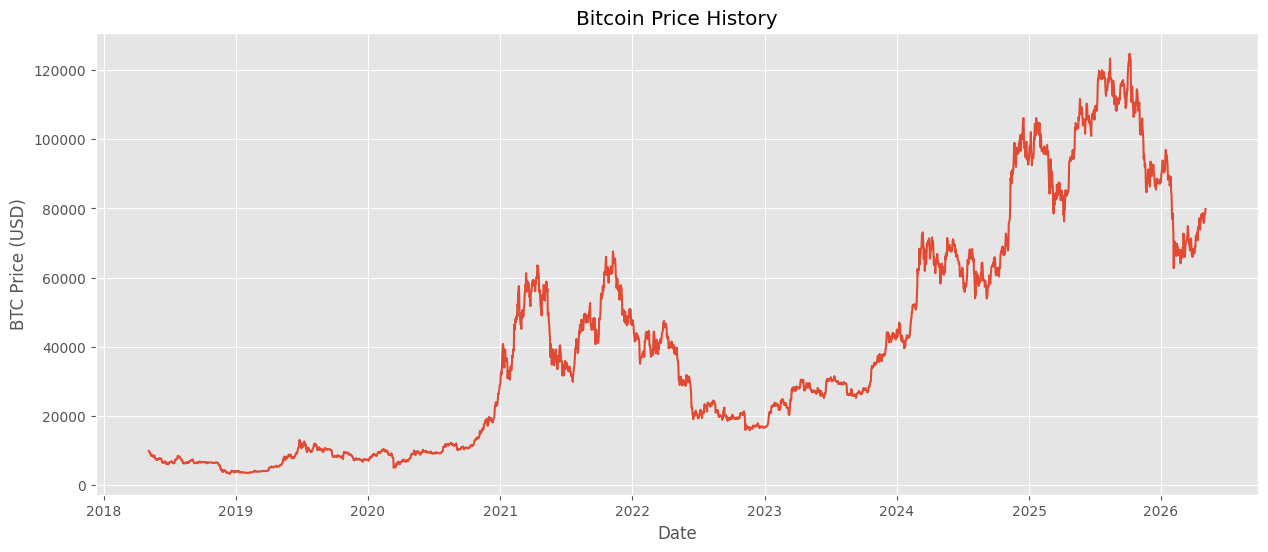

In [32]:
# Plot Bitcoin price history
plt.figure(figsize=(15,6))

plt.plot(
    btc.index,
    btc["Close"]
)

plt.title("Bitcoin Price History")
plt.xlabel("Date")
plt.ylabel("BTC Price (USD)")

plt.show()

### Prepare Weekly Data

All strategies will operate on weekly prices for consistency.

In [33]:
# Convert daily prices to weekly prices
weekly_prices = btc["Close"].resample("W-MON").last()

weekly_prices.head()

# Get column names of weekly_prices
# print(weekly_prices.columns)

Ticker,BTC-USD
Date,
2018-05-07,9373.009766
2018-05-14,8716.790039
2018-05-21,8418.990234
2018-05-28,7135.990234
2018-06-04,7514.470215


### Configure Investment Parameters

We define the base investment amount used in all strategies.

In [34]:
# Base weekly investment amount
weekly_investment = 100

print(f"Base Weekly Investment: ${weekly_investment}")

Base Weekly Investment: $100


### Simulate Dollar Cost Averaging (DCA)

The DCA strategy invests: the same fixed amount every week, regardless of Bitcoin price.

In [35]:
# Create DCA DataFrame
dca = pd.DataFrame(index=weekly_prices.index)

# Store prices
dca["BTC_Price"] = weekly_prices

# Fixed weekly investment
dca["Investment"] = weekly_investment

# BTC purchased each week
dca["BTC_Bought"] = (
    dca["Investment"] / dca["BTC_Price"]
)

# Running BTC accumulation
dca["Total_BTC"] = (
    dca["BTC_Bought"].cumsum()
)

# Total invested amount
dca["Total_Invested"] = (
    dca["Investment"].cumsum()
)

# Portfolio value
dca["Portfolio_Value"] = (
    dca["Total_BTC"] * dca["BTC_Price"]
)

dca.tail()

,BTC_Price,Investment,BTC_Bought,Total_BTC,Total_Invested,Portfolio_Value
Date,,,,,,
2026-04-06,68859.828125,100,0.001452,2.589960,41400,178344.211813
2026-04-13,74484.640625,100,0.001343,2.591303,41500,193012.252124
2026-04-20,75872.523438,100,0.001318,2.592621,41600,196708.676636
2026-04-27,77366.625000,100,0.001293,2.593913,41700,200682.315310
2026-05-04,79827.906250,100,0.001253,2.595166,41800,207166.665408


### Simulate Lump Sum Investing

The Lump Sum strategy: invests the full capital immediately, then holds Bitcoin for the entire period.

For fairness: total invested capital equals the DCA total investment.

In [36]:
# Total capital invested in DCA
total_investment = dca["Investment"].sum()
# print(f"Total Investment: ${total_investment:.2f}")

# First Bitcoin price
first_price = weekly_prices["BTC-USD"].iloc[0]
# print(f"First BTC Price: ${first_price}")

# BTC purchased immediately
lump_btc = (
    total_investment / first_price
)

# Create Lump Sum DataFrame
lump_sum = pd.DataFrame(index=weekly_prices.index)

# Store prices
lump_sum["BTC_Price"] = weekly_prices

# BTC held remains constant
lump_sum["BTC_Held"] = lump_btc

# Portfolio value over time
lump_sum["Portfolio_Value"] = (
    lump_sum["BTC_Held"] * lump_sum["BTC_Price"]
)

lump_sum.head()

,BTC_Price,BTC_Held,Portfolio_Value
Date,,,
2018-05-07,9373.009766,4.459613,41800.000000
2018-05-14,8716.790039,4.459613,38873.513711
2018-05-21,8418.990234,4.459613,37545.441709
2018-05-28,7135.990234,4.459613,31823.757710
2018-06-04,7514.470215,4.459613,33511.632105


### Simulate Martingale Strategy

The Martingale strategy increases investment after price drops.

Rules:
- Normal investment = $100
- If BTC price drops from previous week: double next investment
- Otherwise: reset to normal investment

This strategy attempts to lower average purchase cost during market declines.

In [38]:
# Create Martingale DataFrame
martingale = pd.DataFrame(index=weekly_prices.index)

# Store prices
martingale["BTC_Price"] = weekly_prices

# Initialize columns
martingale["Investment"] = 0.0
martingale["BTC_Bought"] = 0.0

# Initial investment amount
current_investment = weekly_investment

# Loop through weekly prices
for i in range(len(martingale)):

    # Current BTC price
    price = martingale["BTC_Price"].iloc[i]

    # Store investment
    martingale.iloc[i, martingale.columns.get_loc("Investment")] = current_investment

    # Calculate BTC purchased
    btc_bought = current_investment / price

    martingale.iloc[i, martingale.columns.get_loc("BTC_Bought")] = btc_bought

    # Check next week's price movement
    if i < len(martingale) - 1:

        current_price = martingale["BTC_Price"].iloc[i]
        next_price = martingale["BTC_Price"].iloc[i + 1]

        # Double investment after price drop
        if next_price < current_price:
            current_investment *= 2
        else:
            current_investment = weekly_investment

# Running totals
martingale["Total_BTC"] = (
    martingale["BTC_Bought"].cumsum()
)

martingale["Total_Invested"] = (
    martingale["Investment"].cumsum()
)

# Portfolio value
martingale["Portfolio_Value"] = (
    martingale["Total_BTC"] * martingale["BTC_Price"]
)

martingale.tail()

,BTC_Price,Investment,BTC_Bought,Total_BTC,Total_Invested,Portfolio_Value
Date,,,,,,
2026-04-06,68859.828125,100.0,0.001452,19.095375,222400.0,1.314904e+06
2026-04-13,74484.640625,100.0,0.001343,19.096718,222500.0,1.422412e+06
2026-04-20,75872.523438,100.0,0.001318,19.098036,222600.0,1.449016e+06
2026-04-27,77366.625000,100.0,0.001293,19.099328,222700.0,1.477651e+06
2026-05-04,79827.906250,100.0,0.001253,19.100581,222800.0,1.524759e+06


### Compare Portfolio Performance

This chart compares:
- DCA,
- Lump Sum,
- and Martingale portfolio growth over time.

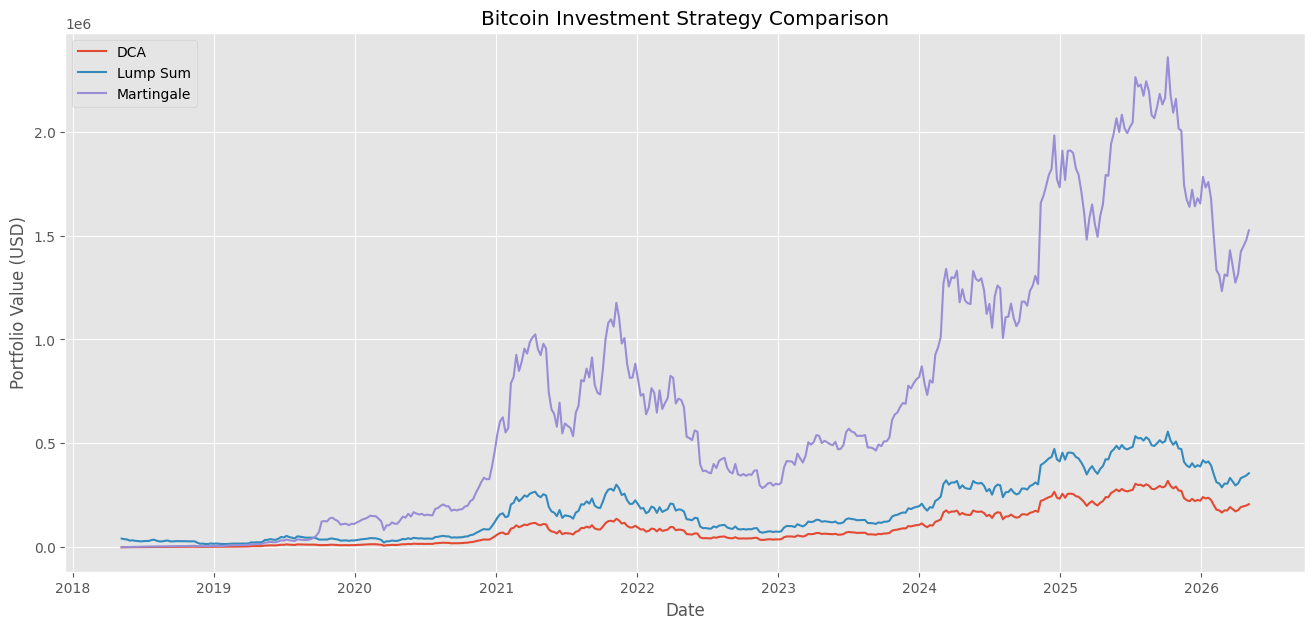

In [39]:
# Create comparison chart
plt.figure(figsize=(16,7))

# DCA strategy
plt.plot(
    dca.index,
    dca["Portfolio_Value"],
    label="DCA"
)

# Lump sum strategy
plt.plot(
    lump_sum.index,
    lump_sum["Portfolio_Value"],
    label="Lump Sum"
)

# Martingale strategy
plt.plot(
    martingale.index,
    martingale["Portfolio_Value"],
    label="Martingale"
)

# Chart formatting
plt.title("Bitcoin Investment Strategy Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value (USD)")
plt.legend()

plt.show()

### Compare Final Results

We summarize: total invested, final portfolio value, and ROI for each strategy.

In [40]:
# Final DCA value
dca_final = dca["Portfolio_Value"].iloc[-1]
dca_invested = dca["Total_Invested"].iloc[-1]

# Final Lump Sum value
lump_final = lump_sum["Portfolio_Value"].iloc[-1]

# Final Martingale value
martingale_final = martingale["Portfolio_Value"].iloc[-1]
martingale_invested = martingale["Total_Invested"].iloc[-1]

# ROI calculations
dca_roi = (
    (dca_final - dca_invested)
    / dca_invested
) * 100

lump_roi = (
    (lump_final - total_investment)
    / total_investment
) * 100

martingale_roi = (
    (martingale_final - martingale_invested)
    / martingale_invested
) * 100

# Display results
print("===== FINAL STRATEGY RESULTS =====\n")

print(f"DCA Final Value: ${dca_final:,.2f}")
print(f"DCA ROI: {dca_roi:.2f}%\n")

print(f"Lump Sum Final Value: ${lump_final:,.2f}")
print(f"Lump Sum ROI: {lump_roi:.2f}%\n")

print(f"Martingale Final Value: ${martingale_final:,.2f}")
print(f"Martingale ROI: {martingale_roi:.2f}%")

===== FINAL STRATEGY RESULTS =====

DCA Final Value: $207,166.67
DCA ROI: 395.61%

Lump Sum Final Value: $356,001.60
Lump Sum ROI: 751.68%

Martingale Final Value: $1,524,759.38
Martingale ROI: 584.36%
